<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import torch
import torch

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup random seed
RANDOM_SEED = 42

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors. 
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [3]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

n_samples = 1000

x, y = make_moons(
    n_samples=n_samples,
    noise=0.2,
    random_state=RANDOM_SEED
)

len(x), len(y)


(1000, 1000)

In [4]:
x.shape, y.shape

((1000, 2), (1000,))

In [5]:
# Turn data into a DataFrame
import pandas as pd

df = pd.DataFrame({"x1": x[:, 0],
                   "x2": x[:, 1],
                   "label": y})

print(df["label"].value_counts(dropna=False))
df.head()

label
1    500
0    500
Name: count, dtype: int64


,x1,x2,label
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


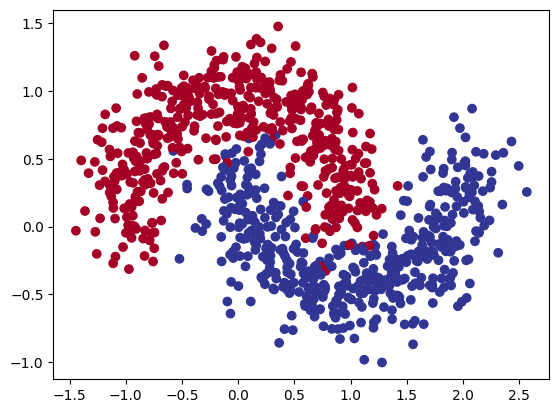

In [6]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt

plt.scatter(x=x[:, 0],
            y=x[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

In [7]:
type(x), type(y)

(numpy.ndarray, numpy.ndarray)

In [8]:
# Turn data into tensors of dtype float
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_SEED)

In [9]:
type(x), type(y)

(torch.Tensor, torch.Tensor)

## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [10]:
import torch
from torch import nn

class MoonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=2, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=16),
            nn.ReLU(),
            nn.Linear(in_features=16, out_features=1)
        )

    def forward(self, x):
        return self.network(x)

my_model = MoonModel().to(device)
my_model


MoonModel(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [11]:
# The same model could also be written directly with nn.Sequential:
# my_model = nn.Sequential(
#     nn.Linear(2, 16),
#     nn.ReLU(),
#     nn.Linear(16, 16),
#     nn.ReLU(),
#     nn.Linear(16, 1)
# ).to(device)


## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [12]:
# Setup loss function
loss_func = nn.BCEWithLogitsLoss()

# Setup optimizer
optimizer = torch.optim.Adam(my_model.parameters(), lr=0.01)


## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [13]:
# Put all data on target device
X_train, y_train = x_train.to(device), y_train.to(device)
X_test, y_test = x_test.to(device), y_test.to(device)


In [14]:
# What's coming out of our model?
my_model.eval()

with torch.inference_mode():
    y_logits = my_model(X_train).squeeze()
    y_probs = torch.sigmoid(y_logits)
    y_preds = torch.round(y_probs)

print(f"Logits (first 5): {y_logits[:5]}")
print(f"Pred probs (first 5): {y_probs[:5]}")
print(f"Pred labels (first 5): {y_preds[:5]}")


Logits (first 5): tensor([0.3768, 0.3967, 0.4174, 0.3941, 0.3357])
Pred probs (first 5): tensor([0.5931, 0.5979, 0.6029, 0.5973, 0.5832])
Pred labels (first 5): tensor([1., 1., 1., 1., 1.])


In [15]:
# TorchMetrics is optional for this exercise.
# This notebook uses a small custom accuracy function below, so no extra package is required.


In [16]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100


In [17]:
# No extra metric import is required because accuracy_fn() is defined above.


In [18]:
# Quick sanity check for the custom accuracy function
accuracy_fn(torch.tensor([0, 1, 1]), torch.tensor([0, 1, 0]))


66.66666666666666

In [19]:
torch.manual_seed(RANDOM_SEED)

epochs = 1000

for epoch in range(epochs):
    # Training
    my_model.train()

    y_logits = my_model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_func(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    my_model.eval()
    with torch.inference_mode():
        test_logits = my_model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_func(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.4f}, Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
        )

# Final binary-classification accuracy
my_model.eval()
with torch.inference_mode():
    final_train_pred = torch.round(torch.sigmoid(my_model(X_train).squeeze()))
    final_test_pred = torch.round(torch.sigmoid(my_model(X_test).squeeze()))

final_train_acc = accuracy_fn(y_train, final_train_pred)
final_test_acc = accuracy_fn(y_test, final_test_pred)

print(f"Final Moon train accuracy: {final_train_acc:.2f}%")
print(f"Final Moon test accuracy:  {final_test_acc:.2f}%")


Epoch: 0 | Loss: 0.7242, Acc: 50.00% | Test Loss: 0.7080, Test Acc: 50.00%
Epoch: 10 | Loss: 0.5724, Acc: 79.25% | Test Loss: 0.5695, Test Acc: 75.50%
Epoch: 20 | Loss: 0.3946, Acc: 81.88% | Test Loss: 0.4086, Test Acc: 80.50%
Epoch: 30 | Loss: 0.3021, Acc: 85.50% | Test Loss: 0.3063, Test Acc: 83.50%
Epoch: 40 | Loss: 0.2488, Acc: 89.00% | Test Loss: 0.2418, Test Acc: 89.00%
Epoch: 50 | Loss: 0.2099, Acc: 91.00% | Test Loss: 0.1950, Test Acc: 91.00%
Epoch: 60 | Loss: 0.1681, Acc: 93.25% | Test Loss: 0.1525, Test Acc: 94.00%
Epoch: 70 | Loss: 0.1311, Acc: 95.75% | Test Loss: 0.1144, Test Acc: 97.00%
Epoch: 80 | Loss: 0.1051, Acc: 96.50% | Test Loss: 0.0869, Test Acc: 97.50%
Epoch: 90 | Loss: 0.0901, Acc: 96.50% | Test Loss: 0.0707, Test Acc: 97.50%
Epoch: 100 | Loss: 0.0811, Acc: 96.75% | Test Loss: 0.0620, Test Acc: 97.50%
Epoch: 110 | Loss: 0.0753, Acc: 97.00% | Test Loss: 0.0555, Test Acc: 97.50%
Epoch: 120 | Loss: 0.0712, Acc: 97.25% | Test Loss: 0.0484, Test Acc: 99.00%
Epoch: 130

Epoch: 240 | Loss: 0.0604, Acc: 97.88% | Test Loss: 0.0391, Test Acc: 99.00%


Epoch: 250 | Loss: 0.0602, Acc: 97.75% | Test Loss: 0.0395, Test Acc: 99.00%
Epoch: 260 | Loss: 0.0600, Acc: 97.62% | Test Loss: 0.0388, Test Acc: 99.00%
Epoch: 270 | Loss: 0.0598, Acc: 97.75% | Test Loss: 0.0383, Test Acc: 99.00%
Epoch: 280 | Loss: 0.0595, Acc: 97.75% | Test Loss: 0.0373, Test Acc: 99.00%
Epoch: 290 | Loss: 0.0592, Acc: 97.75% | Test Loss: 0.0376, Test Acc: 99.00%
Epoch: 300 | Loss: 0.0589, Acc: 97.75% | Test Loss: 0.0375, Test Acc: 99.00%
Epoch: 310 | Loss: 0.0586, Acc: 97.62% | Test Loss: 0.0376, Test Acc: 99.00%
Epoch: 320 | Loss: 0.0584, Acc: 97.62% | Test Loss: 0.0372, Test Acc: 99.00%
Epoch: 330 | Loss: 0.0582, Acc: 97.62% | Test Loss: 0.0378, Test Acc: 99.00%
Epoch: 340 | Loss: 0.0580, Acc: 97.62% | Test Loss: 0.0377, Test Acc: 99.00%
Epoch: 350 | Loss: 0.0578, Acc: 97.62% | Test Loss: 0.0381, Test Acc: 99.00%
Epoch: 360 | Loss: 0.0576, Acc: 97.62% | Test Loss: 0.0380, Test Acc: 99.00%
Epoch: 370 | Loss: 0.0572, Acc: 97.62% | Test Loss: 0.0384, Test Acc: 99.00%

Epoch: 490 | Loss: 0.0547, Acc: 97.50% | Test Loss: 0.0406, Test Acc: 99.00%


Epoch: 500 | Loss: 0.0546, Acc: 97.50% | Test Loss: 0.0404, Test Acc: 99.00%
Epoch: 510 | Loss: 0.0545, Acc: 97.62% | Test Loss: 0.0418, Test Acc: 98.50%
Epoch: 520 | Loss: 0.0544, Acc: 97.75% | Test Loss: 0.0409, Test Acc: 99.00%
Epoch: 530 | Loss: 0.0543, Acc: 97.62% | Test Loss: 0.0421, Test Acc: 98.50%
Epoch: 540 | Loss: 0.0542, Acc: 97.62% | Test Loss: 0.0414, Test Acc: 99.00%
Epoch: 550 | Loss: 0.0541, Acc: 97.62% | Test Loss: 0.0394, Test Acc: 99.00%
Epoch: 560 | Loss: 0.0540, Acc: 97.62% | Test Loss: 0.0410, Test Acc: 99.00%
Epoch: 570 | Loss: 0.0539, Acc: 97.50% | Test Loss: 0.0411, Test Acc: 99.00%
Epoch: 580 | Loss: 0.0538, Acc: 97.62% | Test Loss: 0.0405, Test Acc: 99.00%
Epoch: 590 | Loss: 0.0537, Acc: 97.62% | Test Loss: 0.0413, Test Acc: 99.00%
Epoch: 600 | Loss: 0.0537, Acc: 97.75% | Test Loss: 0.0415, Test Acc: 99.00%
Epoch: 610 | Loss: 0.0536, Acc: 97.62% | Test Loss: 0.0421, Test Acc: 98.50%
Epoch: 620 | Loss: 0.0535, Acc: 97.75% | Test Loss: 0.0422, Test Acc: 98.50%

Epoch: 730 | Loss: 0.0526, Acc: 97.50% | Test Loss: 0.0446, Test Acc: 98.50%


Epoch: 740 | Loss: 0.0526, Acc: 97.62% | Test Loss: 0.0431, Test Acc: 98.50%
Epoch: 750 | Loss: 0.0525, Acc: 97.50% | Test Loss: 0.0451, Test Acc: 98.00%
Epoch: 760 | Loss: 0.0526, Acc: 97.75% | Test Loss: 0.0438, Test Acc: 98.50%
Epoch: 770 | Loss: 0.0523, Acc: 97.88% | Test Loss: 0.0432, Test Acc: 98.50%
Epoch: 780 | Loss: 0.0523, Acc: 97.62% | Test Loss: 0.0412, Test Acc: 99.00%
Epoch: 790 | Loss: 0.0522, Acc: 97.62% | Test Loss: 0.0414, Test Acc: 99.00%
Epoch: 800 | Loss: 0.0522, Acc: 97.62% | Test Loss: 0.0407, Test Acc: 99.00%
Epoch: 810 | Loss: 0.0521, Acc: 97.50% | Test Loss: 0.0424, Test Acc: 99.00%
Epoch: 820 | Loss: 0.0520, Acc: 97.62% | Test Loss: 0.0417, Test Acc: 99.00%
Epoch: 830 | Loss: 0.0522, Acc: 97.62% | Test Loss: 0.0396, Test Acc: 99.00%
Epoch: 840 | Loss: 0.0520, Acc: 97.88% | Test Loss: 0.0441, Test Acc: 98.50%
Epoch: 850 | Loss: 0.0519, Acc: 97.50% | Test Loss: 0.0432, Test Acc: 98.50%
Epoch: 860 | Loss: 0.0518, Acc: 97.50% | Test Loss: 0.0430, Test Acc: 98.50%

Epoch: 970 | Loss: 0.0514, Acc: 97.62% | Test Loss: 0.0432, Test Acc: 99.00%


Epoch: 980 | Loss: 0.0514, Acc: 97.75% | Test Loss: 0.0402, Test Acc: 99.00%
Epoch: 990 | Loss: 0.0515, Acc: 97.88% | Test Loss: 0.0449, Test Acc: 98.00%
Final Moon train accuracy: 97.50%
Final Moon test accuracy:  98.50%


## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [20]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

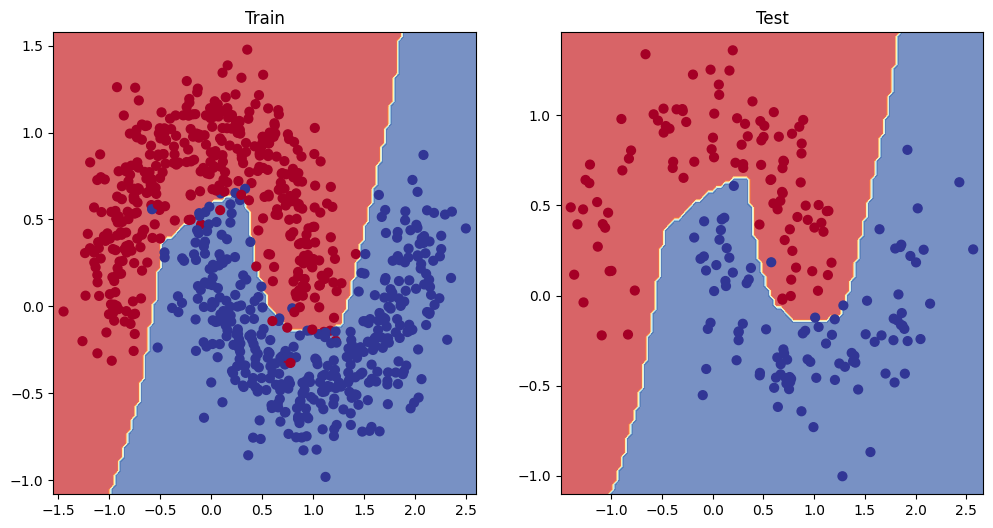

In [21]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(my_model, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(my_model, X_test, y_test) # model_3 = has non-linearity

## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

In [22]:
# Create a straight line tensor
x = torch.arange(-5, 5, 0.1)


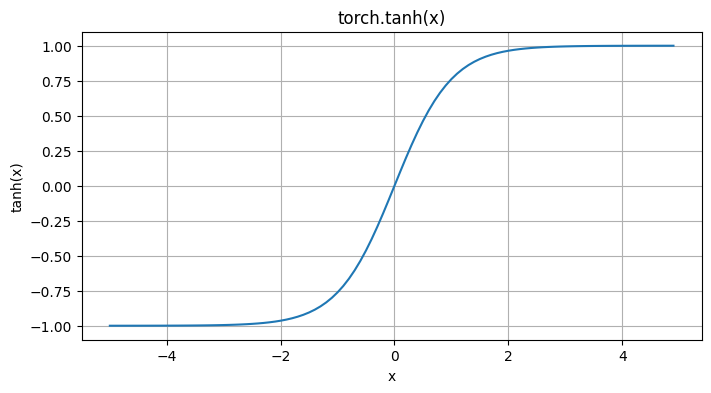

In [23]:
# Test torch.tanh() on the tensor and plot it
y_torch = torch.tanh(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y_torch)
plt.title("torch.tanh(x)")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show()


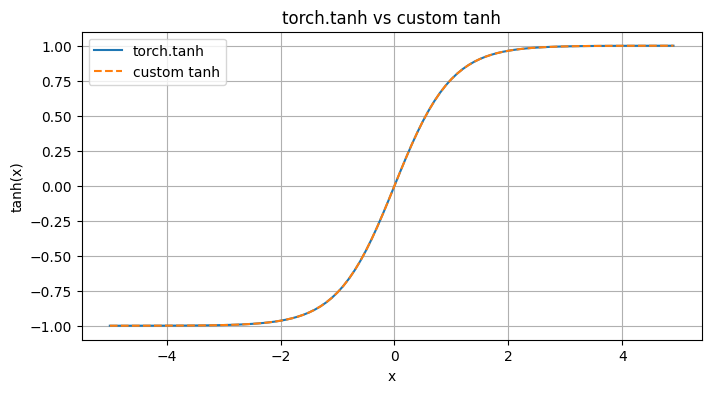

Maximum absolute difference: 1.1920928955078125e-07


In [24]:
# Replicate torch.tanh() in pure PyTorch and plot it
y_custom = (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.figure(figsize=(8, 4))
plt.plot(x, y_torch, label="torch.tanh")
plt.plot(x, y_custom, linestyle="--", label="custom tanh")
plt.title("torch.tanh vs custom tanh")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.legend()
plt.grid(True)
plt.show()

print("Maximum absolute difference:", torch.max(torch.abs(y_torch - y_custom)).item())


## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

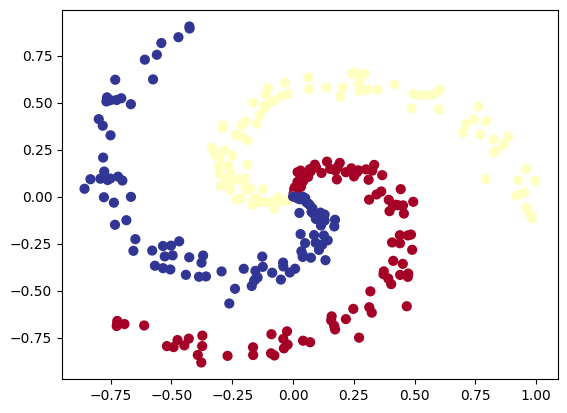

In [25]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [26]:
# Turn data into tensors
import torch
x = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
x_spiral_train, x_spiral_test, y_spiral_train, y_spiral_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_SEED)

In [27]:
# The spiral dataset has 3 classes (0, 1, 2).
num_classes = 3


In [28]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

class Spiral(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=64):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

my_model1 = Spiral(
    input_features=2,
    output_features=3,
    hidden_units=64
).to(device)

my_model1


Spiral(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [29]:
# Setup data to be device agnostic
X_spiral_train = x_spiral_train.to(device)
y_spiral_train = y_spiral_train.to(device)
X_spiral_test = x_spiral_test.to(device)
y_spiral_test = y_spiral_test.to(device)

my_model1.eval()
with torch.inference_mode():
    y_logits = my_model1(X_spiral_train)
    y_probs = torch.softmax(y_logits, dim=1)
    y_preds = y_probs.argmax(dim=1)

print(f"Logits (first 10):\n{y_logits[:10]}")
print(f"Pred probs (first 10):\n{y_probs[:10]}")
print(f"Pred labels (first 10):\n{y_preds[:10]}")


Logits (first 10):
tensor([[-0.0644, -0.0069, -0.0114],
        [-0.0527, -0.0545, -0.0056],
        [-0.0429,  0.0302, -0.0140],
        [ 0.0018, -0.0167, -0.0520],
        [ 0.0047,  0.0054, -0.0337],
        [-0.0106,  0.0151, -0.0206],
        [-0.0225,  0.0212, -0.0161],
        [-0.1108,  0.0335, -0.0202],
        [-0.0189, -0.0388, -0.0140],
        [ 0.0018, -0.0167, -0.0527]])
Pred probs (first 10):
tensor([[0.3212, 0.3402, 0.3387],
        [0.3282, 0.3277, 0.3441],
        [0.3220, 0.3465, 0.3315],
        [0.3414, 0.3351, 0.3235],
        [0.3375, 0.3377, 0.3248],
        [0.3316, 0.3402, 0.3283],
        [0.3278, 0.3424, 0.3298],
        [0.3077, 0.3554, 0.3369],
        [0.3350, 0.3284, 0.3366],
        [0.3415, 0.3352, 0.3233]])
Pred labels (first 10):
tensor([1, 2, 1, 0, 1, 1, 1, 1, 2, 0])


In [30]:
# Setup loss function and optimizer for multiclass classification
loss_func_spiral = nn.CrossEntropyLoss()
optimizer_spiral = torch.optim.Adam(params=my_model1.parameters(), lr=0.01)


In [31]:
# CrossEntropyLoss expects raw logits of shape [N, C]
# and integer class labels of shape [N].


In [32]:
# Build a training loop for the spiral model
torch.manual_seed(RANDOM_SEED)
epochs = 1000

for epoch in range(epochs):
    # Training
    my_model1.train()

    y_logits = my_model1(X_spiral_train)
    y_pred = y_logits.argmax(dim=1)

    loss = loss_func_spiral(y_logits, y_spiral_train)
    acc = accuracy_fn(y_spiral_train, y_pred)

    optimizer_spiral.zero_grad()
    loss.backward()
    optimizer_spiral.step()

    # Testing
    my_model1.eval()
    with torch.inference_mode():
        spiral_test_logits = my_model1(X_spiral_test)
        test_spiral_pred = spiral_test_logits.argmax(dim=1)

        test_loss = loss_func_spiral(spiral_test_logits, y_spiral_test)
        test_acc = accuracy_fn(y_spiral_test, test_spiral_pred)

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.4f}, Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
        )

# Final multiclass accuracy
my_model1.eval()
with torch.inference_mode():
    final_spiral_train_pred = my_model1(X_spiral_train).argmax(dim=1)
    final_spiral_test_pred = my_model1(X_spiral_test).argmax(dim=1)

final_spiral_train_acc = accuracy_fn(y_spiral_train, final_spiral_train_pred)
final_spiral_test_acc = accuracy_fn(y_spiral_test, final_spiral_test_pred)

print(f"Final Spiral train accuracy: {final_spiral_train_acc:.2f}%")
print(f"Final Spiral test accuracy:  {final_spiral_test_acc:.2f}%")


Epoch: 0 | Loss: 1.0955, Acc: 33.33% | Test Loss: 1.0373, Test Acc: 51.67%
Epoch: 100 | Loss: 0.0342, Acc: 99.17% | Test Loss: 0.0073, Test Acc: 100.00%


Epoch: 200 | Loss: 0.0212, Acc: 99.17% | Test Loss: 0.0007, Test Acc: 100.00%


Epoch: 300 | Loss: 0.0174, Acc: 99.17% | Test Loss: 0.0001, Test Acc: 100.00%


Epoch: 400 | Loss: 0.0159, Acc: 99.17% | Test Loss: 0.0000, Test Acc: 100.00%


Epoch: 500 | Loss: 0.0152, Acc: 99.17% | Test Loss: 0.0000, Test Acc: 100.00%


Epoch: 600 | Loss: 0.0221, Acc: 99.17% | Test Loss: 0.0000, Test Acc: 100.00%


Epoch: 700 | Loss: 0.0144, Acc: 99.17% | Test Loss: 0.0000, Test Acc: 100.00%


Epoch: 800 | Loss: 0.0142, Acc: 99.17% | Test Loss: 0.0000, Test Acc: 100.00%


Epoch: 900 | Loss: 0.0141, Acc: 99.17% | Test Loss: 0.0000, Test Acc: 100.00%


Final Spiral train accuracy: 99.17%
Final Spiral test accuracy:  100.00%


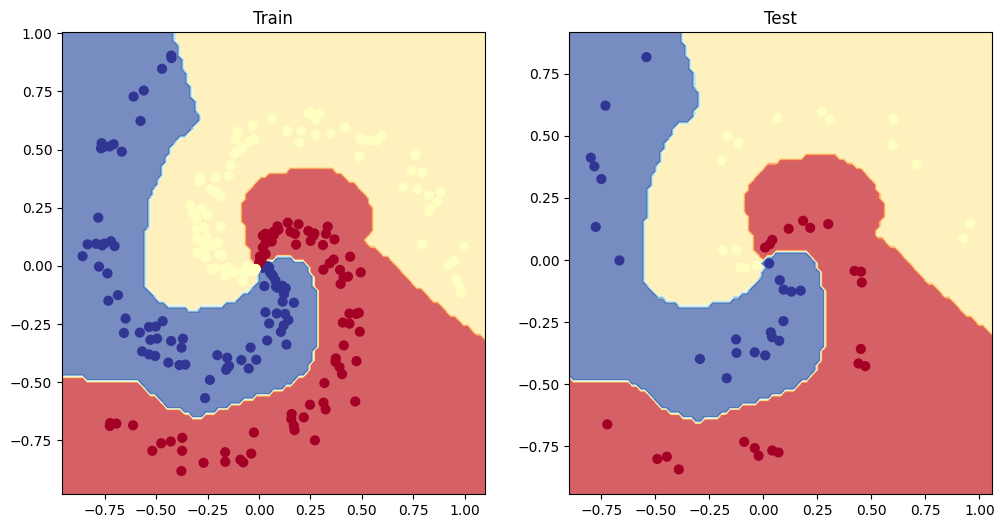

In [33]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(my_model1, X_spiral_train, y_spiral_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(my_model1, X_spiral_test, y_spiral_test)